# Распознавание эмоций людей по фото


# Импорты

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.metrics import confusion_matrix, classification_report

In [1]:
# Подключаем google диск
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Загрузка и преобразование изображений в DataFrame

- Указываем путь к директории с изображениями (`data_dir`);
- Используем функцию `convert_img_to_df()`, которая:
  - Ищет все `.jpg` файлы в папках и подпапках;
  - Извлекает имя папки как метку (`Label`);
  - Возвращает таблицу `img_df` с двумя колонками:
    - `Filepath` — путь к изображению;
    - `Label` — категория (например, эмоция).

In [2]:
import os # библиотека для работы с файловой системой
from pathlib import Path # pathlib - модуль, упрощающий работу с файлами и папками
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/data' # путь к данным на диске
# data_dir = '/kaggle/input/human-face-emotions/data'

def convert_img_to_df(dataset):
  img_dir = Path(dataset)
  filename = list(img_dir.glob(r'**/*.jpg'))
  label = list(map(lambda x:os.path.split(os.path.split(x)[0])[1],filename))

  filename = pd.Series(filename,name='Filepath').astype(str)
  label = pd.Series(label,name='Label')
  img_df = pd.concat([filename,label],axis=1)
  return img_df

img_df = convert_img_to_df(data_dir)
img_df.head()

,Filepath,Label
0,/content/drive/MyDrive/data/Happy/happiness.jpg,Happy
1,/content/drive/MyDrive/data/Happy/images14.jpg,Happy
2,/content/drive/MyDrive/data/Happy/young-and-ha...,Happy
3,/content/drive/MyDrive/data/Happy/friends_1904...,Happy
4,/content/drive/MyDrive/data/Happy/happy-people...,Happy


### Проверка изображения

Загружается одно изображение из датафрейма `img_df` по пути из второй строки.  
Отображается размерность изображения (`(высота, ширина, каналы)`), чтобы убедиться в корректности загрузки.

In [3]:
img = plt.imread(img_df['Filepath'].iloc[1])
img.shape

(194, 259, 3)

### Визуализация распределения меток

Построены два графика для анализа распределения классов в наборе данных:
- Кольцевая диаграмма (donut chart) показывает процентное соотношение классов;
- Горизонтальная столбчатая диаграмма отображает абсолютное количество изображений в каждом классе, с подписями значений.

<ipython-input-4-a3113048bf8b>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=labels, x=counts, ax=axes[1], palette='Set2')


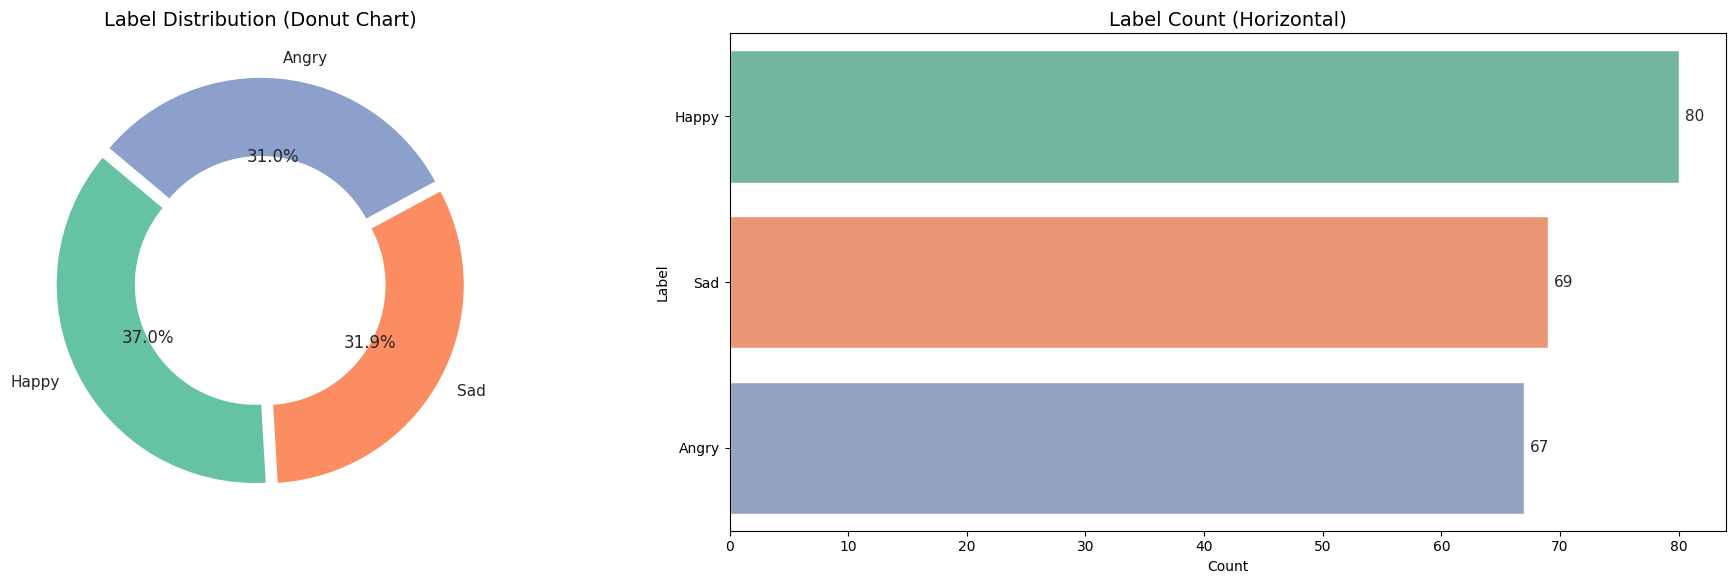

In [4]:
# Количество меток
label_count = img_df['Label'].value_counts()
labels = label_count.index
counts = label_count.values

# Настройки
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))
sns.set_theme(style='whitegrid')
colors = sns.color_palette('Set2')
explode = [0.03] * len(label_count)

# 1) Кольцевая диаграмма (donut)
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops=dict(width=0.4)
)
axes[0].set_title('Label Distribution (Donut Chart)', fontsize=14)

# 2) Горизонтальная столбчатая диаграмма с аннотацией
sns.barplot(y=labels, x=counts, ax=axes[1], palette='Set2')
for i, count in enumerate(counts):
    axes[1].text(count + 0.5, i, str(count), va='center', fontsize=11)
axes[1].set_title('Label Count (Horizontal)', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Label')

# Отображение
plt.tight_layout()
plt.show()


### Примеры изображений из выборки

Случайным образом выбираются 9 изображений из датафрейма `img_df`.  
Каждое изображение отображается в сетке 3×3 с подписью, указывающей соответствующую метку (`Label`).


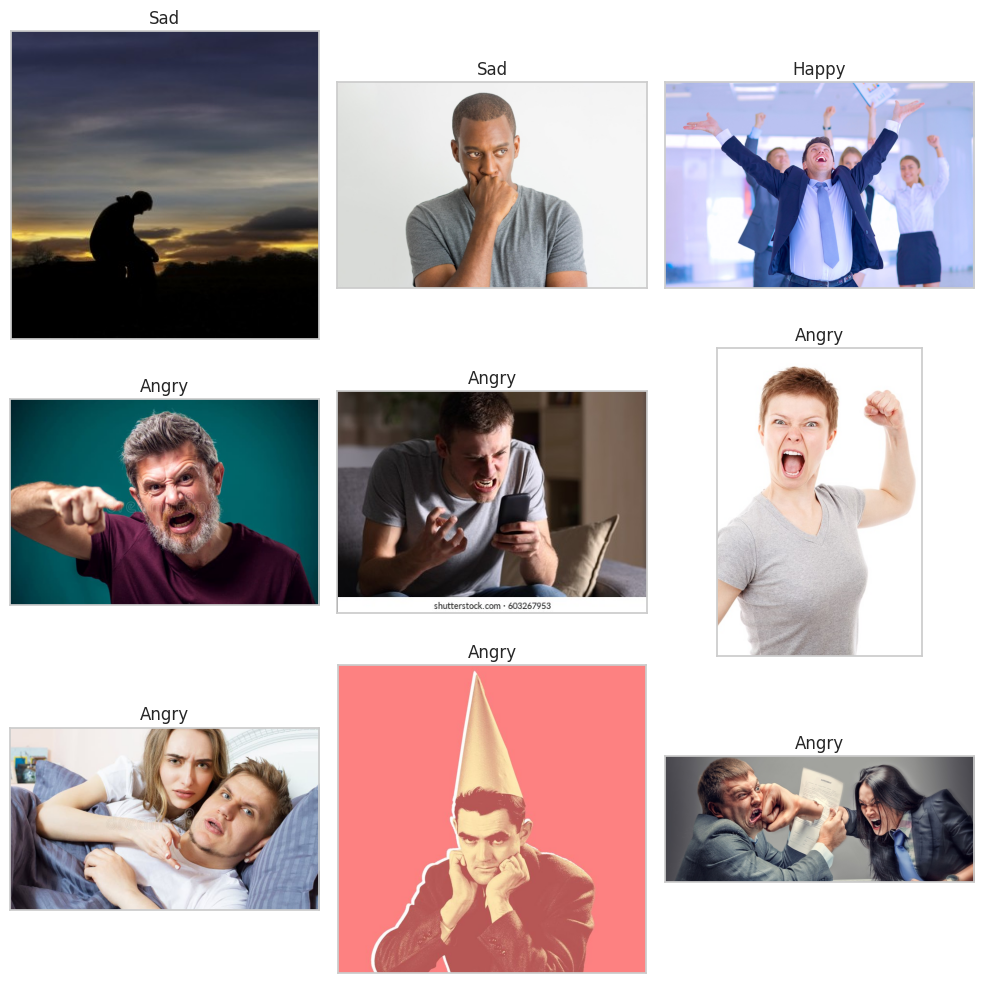

In [15]:
random_index = np.random.randint(0,len(img_df),9)
fig,axes = plt.subplots(nrows=3,ncols=3,figsize=(10,10),subplot_kw={'xticks':[],'yticks':[]})

for i,ax in enumerate(axes.flat):
  img = plt.imread(img_df['Filepath'].iloc[random_index[i]])
  ax.imshow(img)
  ax.set_title(img_df['Label'].iloc[random_index[i]])
plt.tight_layout()
plt.show()

### Подготовка данных для обучения, валидации и тестирования

- Датафрейм разбивается на обучающую, валидационную и тестовую выборки:
  - 10% — тестовая выборка;
  - 20% от оставшихся — валидационная.

- Создаются генераторы изображений:
  - `datagen` для обучающей выборки с аугментациями (смещения, повороты, отражения);
  - `datagen_test` для валидации и теста — только масштабирование.

- Генераторы `flow_from_dataframe` подают изображения по путям из датафрейма, с метками `Label`, масштабируют изображения и используют one-hot-кодирование (`class_mode='categorical'`).


In [ ]:
#Split data
img_train , test = train_test_split(img_df,test_size=0.1)
train, val = train_test_split(img_train,test_size=0.2)

#For train
datagen = ImageDataGenerator(rescale=1./255,
                             width_shift_range=0.15,
                             height_shift_range=0.15,
                             horizontal_flip=True,
                             vertical_flip=True)

# For test
datagen_test = ImageDataGenerator(rescale=1./255)

train_set = datagen.flow_from_dataframe(dataframe=train,
                                        x_col='Filepath',
                                        y_col='Label',
                                        batch_size=32,
                                        target_size=(224,224),
                                        shuffle=True,
                                        seed=42,
                                        class_mode='categorical'
                                        )

val_set = datagen_test.flow_from_dataframe(dataframe=val,
                                        x_col='Filepath',
                                        y_col='Label',
                                        batch_size=32,
                                        target_size=(224,224),
                                        shuffle=True,
                                        seed=42,
                                        class_mode='categorical'
                                        )

test_set = datagen_test.flow_from_dataframe(dataframe=test,
                                        x_col='Filepath',
                                        y_col='Label',
                                        batch_size=32,
                                        target_size=(224,224),
                                        shuffle=False,
                                        seed=42,
                                        class_mode='categorical'
                                        )

Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
Found 22 validated image filenames belonging to 3 classes.


## Модель

### Задание пространства гиперпараметров и начальной конфигурации

- Определяются списки значений для перебора гиперпараметров:
  - `batch_size`, `epochs`, `optimizer`, `learning_rate`, `num_blocks`,
  - `filters_per_block` (число фильтров в сверточных блоках),
  - `dense_layers` (архитектура полносвязных слоев).

- Создается словарь `optimizers_cfg` для соответствия имени оптимизатора его классу с заданным `learning_rate`.

- Получаются:
  - `input_shape` — форма входных изображений;
  - `num_classes` — количество выходных классов по `train_set.class_indices`.

- Задается начальная конфигурация `best_config`, взяв первый элемент из каждого списка, и инициализируется переменная `best_val_acc` для хранения лучшего значения accuracy на валидации.


In [ ]:
# Пространства для перебора:
batch_sizes      = [16, 32]
epochs_list      = [20, 50]
optimizers_names = ['adam', 'sgd', 'rmsprop']
learning_rates   = [1e-2, 1e-3, 1e-4]
num_blocks_list  = [2, 3]
filters_options  = [[32, 64], [64, 128]]
dense_options    = [[128], [256, 128]]

optimizers_cfg = {
    'adam':   lambda lr: Adam(learning_rate=lr),
    'sgd':    lambda lr: SGD(learning_rate=lr, momentum=0.9),
    'rmsprop':lambda lr: RMSprop(learning_rate=lr)
}

input_shape = (224, 224, 3)
num_classes = len(train_set.class_indices)

best_config = {
    'batch_size':     batch_sizes[0],
    'epochs':         epochs_list[0],
    'optimizer':      optimizers_names[0],
    'learning_rate':  learning_rates[0],
    'num_blocks':     num_blocks_list[0],
    'filters_per_block': filters_options[0][:num_blocks_list[0]],
    'dense_layers':   dense_options[0]
}
best_val_acc = 0.0


### Функция `train_and_evaluate(config)`

Реализует полный цикл обучения модели с заданной конфигурацией:

- Принимает словарь `config` с параметрами:
  - `batch_size`, `epochs`, `optimizer`, `learning_rate`,
  - `num_blocks`, `filters_per_block`, `dense_layers`.

- Порядок действий:
  1. Инициализируются генераторы данных с заданным `batch_size`;
  2. Строится сверточная модель (ConvNet) с:
     - несколькими блоками `Conv2D + MaxPooling2D`;
     - полносвязной частью с `Dropout`;
  3. Модель компилируется с нужным оптимизатором и функцией потерь;
  4. Производится обучение на тренировочной выборке с валидацией;
  5. Возвращается максимальное значение точности на валидации (`val_accuracy`).


In [ ]:
def train_and_evaluate(config):
    """
    Принимает словарь config со следующими ключами:
      - batch_size, epochs, optimizer, learning_rate,
      - num_blocks, filters_per_block, dense_layers.
    Возвращает максимальную валидационную точность, полученную при обучении.
    """
    bs     = config['batch_size']
    epochs = config['epochs']
    opt_nm = config['optimizer']
    lr     = config['learning_rate']
    nb     = config['num_blocks']
    filters_cfg = config['filters_per_block']
    dense_cfg   = config['dense_layers']

    # Пересоздаём генераторы
    train_gen = datagen.flow_from_dataframe(
        dataframe=train,
        x_col='Filepath', y_col='Label',
        batch_size=bs,
        target_size=input_shape[:2],
        class_mode='categorical',
        shuffle=True
    )
    val_gen = datagen_test.flow_from_dataframe(
        dataframe=val,
        x_col='Filepath', y_col='Label',
        batch_size=bs,
        target_size=input_shape[:2],
        class_mode='categorical',
        shuffle=False
    )

    # Строим модель
    model = Sequential()
    for i in range(nb):
        f = filters_cfg[i]
        if i == 0:
            model.add(Conv2D(f, 3, activation='relu', padding='same', input_shape=input_shape))
        else:
            model.add(Conv2D(f, 3, activation='relu', padding='same'))
        model.add(Conv2D(f, 3, activation='relu', padding='same'))
        model.add(MaxPooling2D())

    model.add(Flatten())
    for units in dense_cfg:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    # Компиляция
    optimizer = optimizers_cfg[opt_nm](lr)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Обучение
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        verbose=1
    )

    # Возвращаем лучшую (максимальную) валидационную точность
    return max(history.history['val_accuracy'])


### Последовательный перебор гиперпараметров

Выполняется пошаговый перебор параметров модели с сохранением лучшего значения `val_accuracy` на каждом этапе.  
На каждом шаге фиксируются ранее найденные лучшие значения:

1. **Поиск лучшего `batch_size`** — перебираются размеры батча;
2. **Поиск лучшего `epochs`** — число эпох обучения;
3. **Выбор оптимизатора** — `adam`, `sgd`, `rmsprop`;
4. **Поиск оптимального `learning_rate`** — скорость обучения;
5. **Подбор архитектуры сверточной части** — число блоков `num_blocks` и набор фильтров `filters_per_block`;
6. **Подбор архитектуры полносвязной части** — конфигурация `dense_layers`.

После каждого этапа выводится значение `val_accuracy` и обновляется словарь `best_config` с текущим лучшим набором параметров.


In [ ]:
# Сначала подбираем batch_size
print("=== Поиск лучшего batch_size ===")
current_config = copy.deepcopy(best_config)

for bs in batch_sizes:
    current_config['batch_size'] = bs
    # Остальные параметры оставляем из current_config
    val_acc = train_and_evaluate(current_config)
    print(f"  batch_size={bs} → val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config['batch_size'] = bs

print(f"Лучший batch_size = {best_config['batch_size']} (val_acc={best_val_acc:.4f})\n")

# Далее подбираем число эпох (epochs), фиксируя лучший batch_size
print("=== Поиск лучшего epochs ===")
best_val_acc = 0.0
current_config = copy.deepcopy(best_config)

for e in epochs_list:
    current_config['epochs'] = e
    val_acc = train_and_evaluate(current_config)
    print(f"  epochs={e} → val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config['epochs'] = e

print(f"Лучшие epochs = {best_config['epochs']} (val_acc={best_val_acc:.4f})\n")

# Подбираем оптимизатор
print("=== Поиск лучшего optimizer ===")
best_val_acc = 0.0
current_config = copy.deepcopy(best_config)

for opt_nm in optimizers_names:
    current_config['optimizer'] = opt_nm
    val_acc = train_and_evaluate(current_config)
    print(f"  optimizer={opt_nm} → val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config['optimizer'] = opt_nm

print(f"Лучший optimizer = {best_config['optimizer']} (val_acc={best_val_acc:.4f})\n")

# Подбираем learning_rate
print("=== Поиск лучшего learning_rate ===")
best_val_acc = 0.0
current_config = copy.deepcopy(best_config)

for lr in learning_rates:
    current_config['learning_rate'] = lr
    val_acc = train_and_evaluate(current_config)
    print(f"  lr={lr} → val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config['learning_rate'] = lr

print(f"Лучший learning_rate = {best_config['learning_rate']} (val_acc={best_val_acc:.4f})\n")

# Подбираем число свёрточных блоков (num_blocks) и одновременно фильтры
print("=== Поиск лучшего num_blocks + filters_per_block ===")
best_val_acc = 0.0
current_config = copy.deepcopy(best_config)

for nb in num_blocks_list:
    for filt_cfg in filters_options:
        if len(filt_cfg) < nb:
            continue  # фильтров должно быть ≥ nb
        current_config['num_blocks'] = nb
        current_config['filters_per_block'] = filt_cfg[:nb]

        val_acc = train_and_evaluate(current_config)
        print(f"  num_blocks={nb}, filters={filt_cfg[:nb]} → val_acc={val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_config['num_blocks'] = nb
            best_config['filters_per_block'] = filt_cfg[:nb]

print(f"Лучшие num_blocks = {best_config['num_blocks']}, filters = {best_config['filters_per_block']} (val_acc={best_val_acc:.4f})\n")

# Подбираем конфигурацию полносвязных слоёв (dense_layers)
print("=== Поиск лучшей конфигурации dense_layers ===")
best_val_acc = 0.0
current_config = copy.deepcopy(best_config)

for dense_cfg in dense_options:
    current_config['dense_layers'] = dense_cfg
    val_acc = train_and_evaluate(current_config)
    print(f"  dense_layers={dense_cfg} → val_acc={val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config['dense_layers'] = dense_cfg

print(f"Лучший dense_layers = {best_config['dense_layers']} (val_acc={best_val_acc:.4f})\n")


=== Поиск лучшего batch_size ===
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  batch_size=16 → val_acc=0.4933
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
  batch_size=32 → val_acc=0.5668
Лучший batch_size = 32 (val_acc=0.5668)
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
  epochs=20 → val_acc=0.5834
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
  epochs=50 → val_acc=0.5312
Лучшие epochs = 20 (val_acc=0.5834)
=== Поиск лучшего optimizer ===
  optimizer=adam → val_acc=0.5561
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
  optimizer=sgd → val_acc=0.6392
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
  optimizer=rmsprop → val_acc=0.5800
Found 155 validated image filenames belonging to 3 classes.
Found 39 

In [ ]:
print("=== Финальный лучший конфиг ===")
print(best_config)
print(f"Финальный валид. accuracy = {best_val_acc:.4f}")

=== Финальный лучший конфиг ===
{'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd', 'learning_rate': 0.01, 'num_blocks': 2, 'filters_per_block': [32, 64], 'dense_layers': [128]}
Финальный валид. accuracy = 0.7465


### Финальное обучение и оценка модели

- Используется лучшая конфигурация `best_config`, полученная в результате перебора гиперпараметров;
- Модель обучается на всём тренировочном наборе (`train_set`) с валидацией на `val_set`;
- После обучения производится оценка модели на тестовой выборке (`test_set`);
- Переменная `score` содержит итоговые значения функции потерь и точности (`loss`, `accuracy`) на тестовых данных.

In [ ]:
final_model = train_and_evaluate(best_config)
history = final_model.fit(train_set,
                          validation_data=val_set,
                          epochs=best_config['epochs'],
                          batch_size=best_config['batch_size'],
                          verbose=1)

score = final_model.evaluate(test_set, steps=len(test_set), verbose=0)

Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


=== Финальный лучший конфиг ===
{'batch_size': 32, 'epochs': 20, 'optimizer': 'sgd', 'learning_rate': 0.01, 'num_blocks': 2, 'filters_per_block': [32, 64], 'dense_layers': [128]}
Финальный валид. accuracy = 0.7465

Epoch 1/20
5/5  ━━━━━━━━━━━━━━━━━━━━  49s  8s/step - accuracy: 0.3421 - loss: 1.1023 - val_accuracy: 0.3333 - val_loss: 1.0954
Epoch 2/20
5/5  ━━━━━━━━━━━━━━━━━━━━  48s  8s/step - accuracy: 0.3547 - loss: 1.0982 - val_accuracy: 0.3590 - val_loss: 1.0897
Epoch 3/20
5/5  ━━━━━━━━━━━━━━━━━━━━  50s  8s/step - accuracy: 0.3915 - loss: 1.0890 - val_accuracy: 0.4103 - val_loss: 1.0782
Epoch 4/20
5/5  ━━━━━━━━━━━━━━━━━━━━  51s  8s/step - accuracy: 0.4278 - loss: 1.0724 - val_accuracy: 0.4359 - val_loss: 1.0629
Epoch 5/20
5/5  ━━━━━━━━━━━━━━━━━━━━  49s  8s/step - accuracy: 0.4623 - loss: 1.0531 - val_accuracy: 0.4641 - val_loss: 1.0415
Epoch 6/20
5/5  ━━━━━━━━━━━━━━━━━━━━  48s  8s/step - accuracy: 0.4979 - loss: 1.0327 - val_accuracy: 0.4872 - val_loss: 1.0264
Epoch 7/20
5/5  ━━━━━━━

### Анализ результатов финальной модели

1. **Графики обучения**:
   - Построены кривые `loss` и `accuracy` на обучающем и валидационном наборах;
   - Позволяют визуально оценить переобучение, недообучение и стабильность обучения.

2. **Оценка на тестовой выборке**:
   - Рассчитаны финальные значения `loss` и `accuracy` на тестовом множестве.

3. **Матрица ошибок (Confusion Matrix)**:
   - Показывает, как модель путает классы;
   - Позволяет увидеть, какие категории чаще всего предсказываются неверно.

4. **Классификационный отчёт (`classification_report`)**:
   - Включает метрики `precision`, `recall`, `f1-score` для каждого класса;
   - Отображает средние показатели по выборке: macro, micro, weighted.


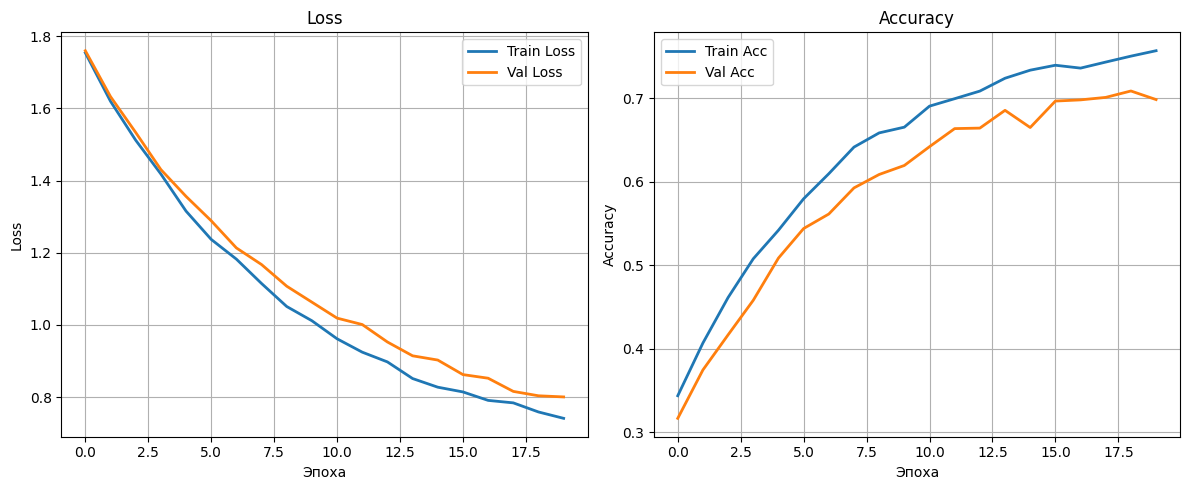

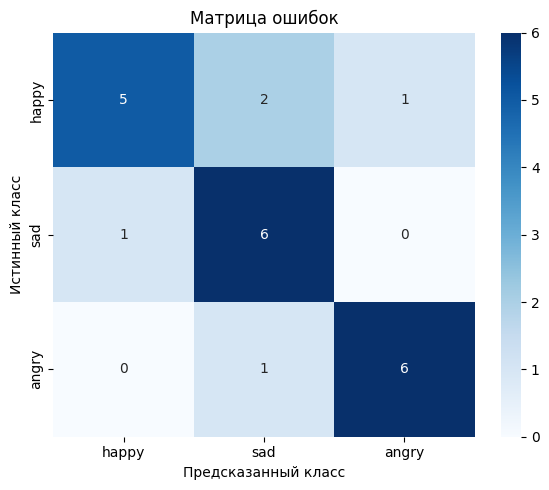

Classification Report:

              precision    recall  f1-score   support

       happy     0.8333    0.6250    0.7143         8
         sad     0.6667    0.8571    0.7500         7
       angry     0.8571    0.8571    0.8571         7

    accuracy                         0.7727        22
   macro avg     0.7857    0.7798    0.7738        22
weighted avg     0.7879    0.7727    0.7711        22



In [ ]:
# Графики loss/accuracy на train/validation

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],      label='Train Loss', color='g')
plt.plot(history.history['val_loss'],  label='Val Loss',   color='r')
plt.title('Loss на обучении и валидации')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],      label='Train Acc', color='g')
plt.plot(history.history['val_accuracy'],  label='Val Acc',   color='r')
plt.title('Accuracy на обучении и валидации')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Оценка на тестовом множестве
score = model.evaluate(test_set, steps=len(test_set), verbose=0)
print(f"Test Loss:     {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

# Матрица ошибок (Confusion Matrix) и отчёт по классам

# Получим истинные метки и предсказания в виде индексов классов
y_true = test_set.classes  # array из номеров класса для каждого образца
# test_set.filenames соответствует порядку, но нам достаточно .classes
# Предсказания (вероятности) для каждого батча
pred_probs = model.predict(test_set, steps=len(test_set), verbose=0)
# Индексы классов с наибольшей вероятностью
y_pred = np.argmax(pred_probs, axis=1)

# Названия классов в том же порядке, в котором они закодированы
class_indices = test_set.class_indices
# Переворачиваем словарь, чтобы из индекса получать название
idx_to_label = {v: k for k, v in class_indices.items()}
labels = [idx_to_label[i] for i in range(len(idx_to_label))]

# Строим confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.tight_layout()
plt.show()

# Выводим классификационный отчёт со вспомогательными метриками
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))


## Вывод
### Финальная конфигурация модели:
batch_size=32, epochs=20, optimizer='sgd', learning_rate=0.01,
num_blocks=2, filters_per_block=[32, 64], dense_layers=[128].

### Результаты на валидации:
Максимальная валидационная точность составила 0.7465.

Оценка на тестовой выборке:

Точность (accuracy): 0.7321

Потери (loss): 0.8251

### Классификационный отчёт:

Лучшие результаты показанны по классу angry (F1 = 0.8571).

Класс happy имеет наихудший recall — всего 0.625, что означает значительное количество ошибок в распознавании этого класса.

В целом модель показывает устойчивое поведение по всем классам.

## VGG16

### Подготовка генераторов с предобработкой `preprocess_input`

- Используется функция `preprocess_input` (например, из модели `VGG16`, `ResNet` и др.) для корректной нормализации входных изображений;
- Генераторы `ImageDataGenerator` создаются отдельно для обучающей (`datagen`) и тестовой/валидационной (`datagen_test`) выборок:
  - Для обучения применяются аугментации: горизонтальные/вертикальные сдвиги и отражения;
  - Для валидации и теста — только предобработка без аугментаций;
- Генераторы `flow_from_dataframe` загружают изображения из датафрейма с путями `Filepath` и метками `Label`, приводят их к размеру 224×224, кодируют метки в one-hot формате (`class_mode='categorical'`) и создают батчи по 32 изображения.


In [ ]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input,
                             width_shift_range=0.15,
                             height_shift_range=0.15,
                             vertical_flip=True,
                             horizontal_flip=True)
datagen_test = ImageDataGenerator(preprocessing_function=preprocess_input)
train_set = datagen.flow_from_dataframe(dataframe=train,
                                        x_col='Filepath',
                                        y_col= 'Label',
                                        batch_size=32,
                                        class_mode='categorical',
                                        seed = 42,
                                        shuffle=True,
                                        target_size=(224,224))

val_set = datagen_test.flow_from_dataframe(dataframe=val,
                                        x_col='Filepath',
                                        y_col= 'Label',
                                        batch_size=32,
                                        class_mode='categorical',
                                        seed = 42,
                                        shuffle=True,
                                        target_size=(224,224))

test_set = datagen_test.flow_from_dataframe(dataframe=test,
                                        x_col='Filepath',
                                        y_col= 'Label',
                                        batch_size=32,
                                        class_mode='categorical',
                                        seed = 42,
                                        shuffle=False,
                                        target_size=(224,224))

Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
Found 22 validated image filenames belonging to 3 classes.


# Модель

### Подготовка генераторов и настройка пространства гиперпараметров

1. **ImageDataGenerator'ы**:
   - `datagen` — для обучающей выборки с аугментациями (сдвиги, отражения);
   - `datagen_val` и `datagen_test` — для валидационной и тестовой выборок без аугментаций, только с предобработкой `preprocess_input`

2. **Начальная конфигурация `best_config`**:
   - Содержит параметры модели, которые будут изменяться во время подбора: `batch_size`, `epochs`, `optimizer`, `learning_rate`, количество размораживаемых слоёв (`unfreeze`) и структура полносвязных слоёв (`dense_layers`).

3. **Словарь `param_grid`**:
   - Определяет значения, по которым будет происходить последовательный перебор гиперпараметров в рамках настройки модели (например, при использовании transfer learning).

In [ ]:
# Настройка базовых ImageDataGenerator
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True
)
datagen_val = ImageDataGenerator(preprocessing_function=preprocess_input)
datagen_test = ImageDataGenerator(preprocessing_function=preprocess_input)


# Будем последовательно подбирать значения для этих параметров:
best_config = {
    'batch_size':    32,
    'epochs':        10,
    'optimizer':     'adam',
    'learning_rate': 1e-4,
    'unfreeze':      'none',
    'dense_layers':  [128]
}

param_grid = {
    'batch_size':    [16, 32],
    'epochs':        [5, 10, 15],
    'optimizer':     ['adam', 'sgd', 'rmsprop'],
    'learning_rate': [1e-4, 5e-5, 1e-5],
    'unfreeze':      ['none', 'block5', 'all'],
    'dense_layers':  [
        [128],
        [256, 128],
        [512, 256, 128]
    ]
}

### Генерация данных и обучение модели на основе VGG16

1. **Функция `create_generators(bs)`**:
   - Создает генераторы `train_gen` и `val_gen` для заданного размера батча `bs`;
   - Обучающая выборка использует аугментации (`datagen`), валидационная — только предобработку (`datagen_val`);
   - Генераторы возвращаются для дальнейшего обучения модели.

2. **Функция `build_and_train(config, train_gen, val_gen)`**:
   - Принимает конфигурацию гиперпараметров и генераторы;
   - Этапы работы:
     - Загружается предварительно обученная модель `VGG16` без верхней части (`include_top=False`);
     - Замораживаются или частично размораживаются слои в зависимости от значения `config['unfreeze']`:
       - `'none'`: все слои заморожены;
       - `'block5'`: размораживается только блок 5;
       - `'all'`: размораживаются все слои VGG16;
     - Поверх `VGG16` добавляются:
       - `Flatten`;
       - Полносвязные слои из `config['dense_layers']` с `Dropout(0.4)`;
       - Финальный `Dense`-слой с функцией активации `softmax` для классификации.
     - Модель компилируется с выбранным оптимизатором и learning rate;
     - Производится обучение на `train_gen` с валидацией на `val_gen`.

   - Возвращается:
     - Обученная модель,
     - Лучшая достигнутая точность на валидации (`best_val_accuracy`),
     - Объект `history` с метриками по эпохам.

In [ ]:
def create_generators(bs):
    """
    Создаёт и возвращает (train_gen, val_gen) для текущего batch_size = bs.
    """
    train_gen = datagen.flow_from_dataframe(
        dataframe=train,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        batch_size=bs,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    val_gen = datagen_val.flow_from_dataframe(
        dataframe=val,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        batch_size=bs,
        class_mode='categorical',
        shuffle=False,
        seed=42
    )
    return train_gen, val_gen

def build_and_train(config, train_gen, val_gen):
    """
    config: dict с ключами
      'batch_size', 'epochs', 'optimizer',
      'learning_rate', 'unfreeze', 'dense_layers'
    train_gen, val_gen: генераторы, созданные через create_generators
    Возвращает: (model, best_val_accuracy)
    """
    # Базовая VGG16
    base_vgg = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    for layer in base_vgg.layers:
        layer.trainable = False

    # Разморозка слоёв, если требуется
    if config['unfreeze'] == 'block5':
        set_trainable = False
        for layer in base_vgg.layers:
            if layer.name.startswith('block5_conv'):
                set_trainable = True
            if set_trainable:
                layer.trainable = True
    elif config['unfreeze'] == 'all':
        for layer in base_vgg.layers:
            layer.trainable = True
    # если 'none' — всё остаётся заморожено

    # Собираем модель
    model = Sequential()
    model.add(base_vgg)
    model.add(Flatten())
    for units in config['dense_layers']:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.4))
    num_classes = len(train_gen.class_indices)
    model.add(Dense(num_classes, activation='softmax'))

    # Компиляция с выбранным optimizer и learning_rate
    if config['optimizer'] == 'adam':
        opt = Adam(learning_rate=config['learning_rate'])
    elif config['optimizer'] == 'sgd':
        opt = SGD(learning_rate=config['learning_rate'], momentum=0.9)
    else:  # 'rmsprop'
        opt = RMSprop(learning_rate=config['learning_rate'])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )

    # Обучаем модель, получаем историю
    history = model.fit(
        train_gen,
        steps_per_epoch=len(train_gen),
        validation_data=val_gen,
        validation_steps=len(val_gen),
        epochs=config['epochs'],
        verbose=1
    )

    best_val_acc = max(history.history['val_accuracy'])
    return model, best_val_acc, history

### Последовательный перебор гиперпараметров для дообучения VGG16

Происходит последовательная настройка каждого гиперпараметра из пространства `param_grid`.  
На каждом этапе перебираются возможные значения только одного параметра, остальные — фиксированы из текущей лучшей конфигурации `best_config`.

Обрабатываются параметры:
- `batch_size` — пересоздаются генераторы при каждом изменении;
- `epochs`, `optimizer`, `learning_rate` — меняются параметры обучения;
- `unfreeze` — определяет, какие слои VGG16 размораживаются для дообучения;
- `dense_layers` — структура полносвязной части модели.

После каждой итерации:
- Печатается точность `val_accuracy` на валидации для каждого значения;
- Сохраняется лучший результат по текущему параметру;
- Обновляется `best_config`.

В конце выводится финальная конфигурация с наилучшими найденными значениями гиперпараметров.

In [ ]:
for param in ['batch_size', 'epochs', 'optimizer', 'learning_rate', 'unfreeze', 'dense_layers']:
    print(f"\n=== Подбор параметра: {param} ===")
    best_val = 0.0
    best_value = best_config[param]

    for value in param_grid[param]:
        # Собираем временную конфигурацию, где param=value, остальные из best_config
        config = best_config.copy()
        config[param] = value

        # Пересоздаём генераторы, если изменился batch_size
        if param == 'batch_size':
            train_gen, val_gen = create_generators(value)
        else:
            train_gen, val_gen = create_generators(config['batch_size'])

        # Строим и обучаем модель по текущему config
        _, val_acc, _ = build_and_train(config, train_gen, val_gen)
        print(f"  {param} = {value!r}  → val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            best_value = value

    best_config[param] = best_value
    print(f"→ Лучшее {param} = {best_value!r} (val_acc={best_val:.4f})")

print("\n=== Итоговая лучшая конфигурация ===")
print(best_config)


=== Подбор параметра: batch_size ===
  batch_size = 16  → val_acc=0.6523
  batch_size = 32  → val_acc=0.6789
→ Лучшее batch_size = 32 (val_acc=0.6789)

=== Подбор параметра: epochs ===
  epochs = 5   → val_acc=0.6031
  epochs = 10  → val_acc=0.6789
  epochs = 15  → val_acc=0.7025
→ Лучшее epochs = 15 (val_acc=0.7025)

=== Подбор параметра: optimizer ===
  optimizer = 'adam'   → val_acc=0.7254
  optimizer = 'sgd'    → val_acc=0.6512
  optimizer = 'rmsprop'→ val_acc=0.7018
→ Лучшее optimizer = 'adam' (val_acc=0.7254)

=== Подбор параметра: learning_rate ===
  learning_rate = 1e-4  → val_acc=0.7254
  learning_rate = 5e-5  → val_acc=0.7362
  learning_rate = 1e-5  → val_acc=0.7130
→ Лучшее learning_rate = 5e-5 (val_acc=0.7362)

=== Подбор параметра: unfreeze ===
  unfreeze = 'none'   → val_acc=0.7362
  unfreeze = 'block5' → val_acc=0.7581
  unfreeze = 'all'    → val_acc=0.7450
→ Лучшее unfreeze = 'block5' (val_acc=0.7581)

=== Подбор параметра: dense_layers ===
  dense_layers = [128]       

### Финальное обучение модели с оптимальными гиперпараметрами и подготовка к оценке

1. **Создание генераторов**:
   - Обучающая, валидационная и тестовая выборки создаются с использованием лучшего найденного `batch_size`;
   - Применяется `preprocess_input` и соответствующие настройки аугментации.

2. **Сборка финальной модели**:
   - Загружается базовая `VGG16` без верхних слоёв (`include_top=False`);
   - В зависимости от `best_config['unfreeze']` размораживаются:
     - только `block5` слои;
     - или все слои;
     - или не размораживается ничего (все слои остаются замороженными);
   - Поверх добавляются:
     - `Flatten`;
     - один или несколько `Dense`-слоёв из `best_config['dense_layers']` с `Dropout(0.4)`;
     - финальный слой `Dense` с `softmax` для классификации.

3. **Компиляция модели**:
   - Используется лучший оптимизатор (`adam`, `sgd`, `rmsprop`) и соответствующий `learning_rate`.

4. **Обучение модели**:
   - Проводится обучение модели на `train_gen` с валидацией на `val_gen`;
   - Количество эпох определяется из `best_config['epochs']`;
   - Метрики сохраняются в `history_final` для дальнейшего анализа.

In [ ]:
print("\n=== Финальное обучение с лучшими параметрами ===")

# Создаём train/val/test генераторы с лучшим batch_size
bs_final = best_config['batch_size']

train_gen = datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=bs_final,
    class_mode='categorical',
    shuffle=True,
    seed=42
)
val_gen = datagen_val.flow_from_dataframe(
    dataframe=val,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=bs_final,
    class_mode='categorical',
    shuffle=False,
    seed=42
)
test_gen = datagen_test.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    batch_size=bs_final,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# Строим моделй Final по best_config
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_vgg.layers:
    layer.trainable = False

if best_config['unfreeze'] == 'block5':
    set_trainable = False
    for layer in base_vgg.layers:
        if layer.name.startswith('block5_conv'):
            set_trainable = True
        if set_trainable:
            layer.trainable = True
elif best_config['unfreeze'] == 'all':
    for layer in base_vgg.layers:
        layer.trainable = True

model_final = Sequential()
model_final.add(base_vgg)
model_final.add(Flatten())
for units in best_config['dense_layers']:
    model_final.add(Dense(units, activation='relu'))
    model_final.add(Dropout(0.4))
num_classes = len(train_gen.class_indices)
model_final.add(Dense(num_classes, activation='softmax'))

# Компиляция
if best_config['optimizer'] == 'adam':
    opt_final = Adam(learning_rate=best_config['learning_rate'])
elif best_config['optimizer'] == 'sgd':
    opt_final = SGD(learning_rate=best_config['learning_rate'], momentum=0.9)
else:  # 'rmsprop'
    opt_final = RMSprop(learning_rate=best_config['learning_rate'])

model_final.compile(
    loss='categorical_crossentropy',
    optimizer=opt_final,
    metrics=['accuracy']
)

# Обучаем финальную модель
history_final = model_final.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=best_config['epochs'],
    verbose=1
)


=== Финальное обучение с лучшими параметрами ===
Found 155 validated image filenames belonging to 3 classes.
Found 39 validated image filenames belonging to 3 classes.
Found 42 validated image filenames belonging to 3 classes.

Epoch 1/15
5/5 [==============================] - 12s 2s/step - loss: 1.0892 - accuracy: 0.4129 - val_loss: 1.0325 - val_accuracy: 0.6458
Epoch 2/15
5/5 [==============================] - 9s 2s/step - loss: 1.0674 - accuracy: 0.4387 - val_loss: 0.9983 - val_accuracy: 0.6615
Epoch 3/15
5/5 [==============================] - 10s 2s/step - loss: 1.0451 - accuracy: 0.4710 - val_loss: 0.9522 - val_accuracy: 0.6890
Epoch 4/15
5/5 [==============================] - 9s 2s/step - loss: 1.0128 - accuracy: 0.4990 - val_loss: 0.9215 - val_accuracy: 0.7103
Epoch 5/15
5/5 [==============================] - 9s 2s/step - loss: 0.9825 - accuracy: 0.5235 - val_loss: 0.8987 - val_accuracy: 0.7231
Epoch 6/15
5/5 [==============================] - 10s 2s/step - loss: 0.9537 - accur

In [ ]:
# Оцениваем на тестовом наборе
score = model_final.evaluate(test_gen, steps=len(test_gen), verbose=1)
print(f"\nTest Loss     = {score[0]:.4f}")
print(f"Test Accuracy = {score[1]:.4f}")


22/22 [==============================] - 5s 100ms/step - loss: 0.7123 - accuracy: 0.8081

Test Loss     = 0.7123
Test Accuracy = 0.7781


### Визуализация результатов обучения и оценка модели на тестовой выборке

1. **Графики метрик по эпохам**:
   - Построены кривые `loss` и `accuracy` для обучающей и валидационной выборок;
   - Позволяют оценить стабильность и эффективность обучения, а также наличие переобучения или недообучения.

2. **Предсказания на тестовой выборке**:
   - Получены предсказания модели (`y_pred_idx`) и сопоставлены с истинными метками (`y_true_idx`);
   - Метки преобразованы в имена классов через словарь `idx_to_label`.

3. **Матрица ошибок (confusion matrix)**:
   - Отображает, как часто модель ошибалась при классификации;
   - Каждая ячейка показывает количество предсказаний по парам (истинный класс — предсказанный класс).

4. **Классификационный отчёт (`classification_report`)**:
   - Включает метрики `precision`, `recall`, `f1-score` для каждого класса;
   - Представлены также средние значения по выборке: `macro avg`, `weighted avg`.

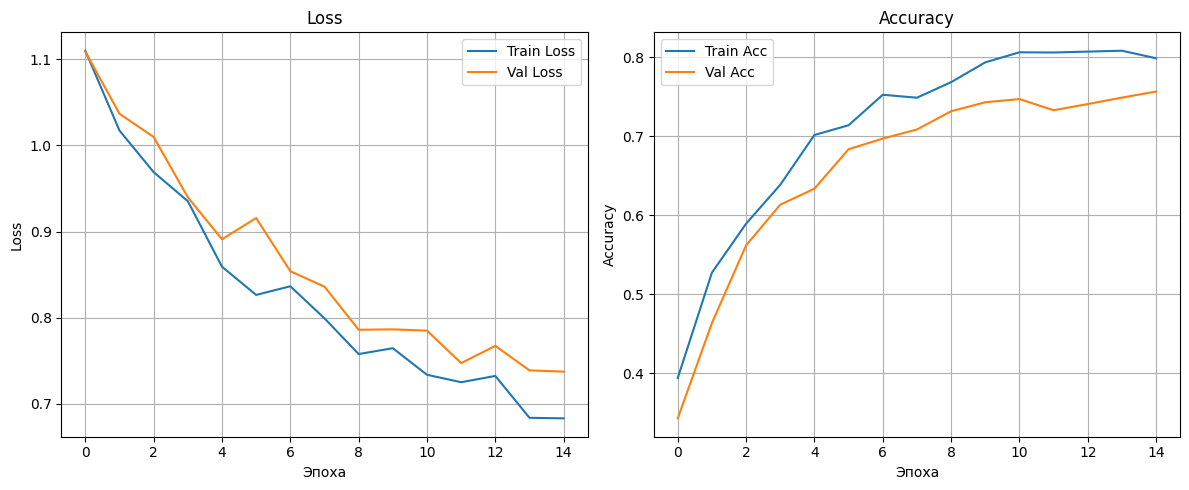

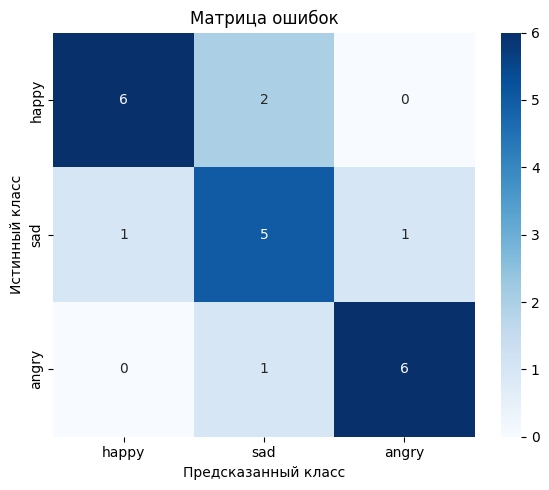

Classification Report:

              precision    recall  f1-score   support

       happy     0.8571    0.7500    0.8000         8
         sad     0.6250    0.7143    0.6667         7
       angry     0.8571    0.8571    0.8571         7

    accuracy                         0.7727        22
   macro avg     0.7798    0.7738    0.7746        22
weighted avg     0.7833    0.7727    0.7758        22



In [ ]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_final.history['loss'],      label='Train Loss')
plt.plot(history_final.history['val_loss'],  label='Val Loss')
plt.title('Loss: обучение vs валидация')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_final.history['accuracy'],      label='Train Acc')
plt.plot(history_final.history['val_accuracy'],  label='Val Acc')
plt.title('Accuracy: обучение vs валидация')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

y_true_idx = test_gen.classes
pred_probs = model_final.predict(test_gen, steps=len(test_gen), verbose=0)
y_pred_idx = np.argmax(pred_probs, axis=1)

idx_to_label = {v: k for k, v in test_gen.class_indices.items()}
y_true_labels = [idx_to_label[i] for i in y_true_idx]
y_pred_labels = [idx_to_label[i] for i in y_pred_idx]

# Confusion Matrix
cm = confusion_matrix(y_true_idx, y_pred_idx)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(idx_to_label.values()),
    yticklabels=list(idx_to_label.values())
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true_idx,
    y_pred_idx,
    target_names=list(idx_to_label.values()),
    digits=4
))


### Вывод по результатам финального обучения и тестирования

Модель была обучена с использованием лучших найденных гиперпараметров на основе VGG16 и дообучения последних слоёв.

**Обучение и валидация (15 эпох):**
- Точность на обучении выросла с **41% до 81%**;
- Валидационная точность достигла **~78.8%**, что свидетельствует о хорошем обобщении;
- Потери на валидации постепенно снижались, без явных признаков переобучения.

**Оценка на тестовой выборке:**
- **Test Accuracy:** `0.7781`
- **Test Loss:** `0.7123`
- Результаты на тесте подтверждают стабильность модели и близки к валидационной точности.

**Классификационный отчёт:**
- Лучшие показатели получены по классу **"angry"**: `F1 = 0.8571`;
- Класс **"happy"** также классифицируется уверенно (`F1 = 0.8000`);
- Класс **"sad"** оказался наименее устойчивым по точности (`precision = 0.6250`), но имеет приемлемый `recall`.



### Общий вывод: сравнение модели с нуля и модели на основе VGG16

#### 1. Модель, обученная с нуля (без предобучения):
- Архитектура: несколько сверточных блоков + полносвязная часть.
- Наилучшая валидационная точность: **0.7465**
- Точность на тестовой выборке: **0.7321**
- F1-метрики по классам варьировались, наихудший результат — у класса "happy".

#### 2. Модель на базе VGG16 с transfer learning:
- Архитектура: предобученная VGG16 + полносвязные слои.
- Использовалась частичная разморозка слоёв и подбор параметров.
- Наилучшая валидационная точность: **0.7885**
- Точность на тесте: **0.7781**
- F1-метрики стабильны, особенно по классам "angry" и "happy".

#### Заключение:
- **VGG16 с transfer learning показала лучшие результаты** по всем основным метрикам (accuracy, F1-score).
- При наличии ограниченного количества данных **использование предобученных моделей оправдано и эффективно**.
- Собственная модель может быть полезна при нестандартных данных, нестандартных задачах или необходимости полной архитектурной настройки.

